# The bottleneck decides everything (Amdahl's law for queueing networks)

A request in a microservice mesh visits several services. Intuition says "speed up the slowest
service". Almost: speed up the service with the highest **demand** `D_i = e_i · b_i` — visits
times service time — because utilization at node i is `ρ_i = λ · D_i`. A node visited 3 times
with a modest service time can out-bottleneck a slow node visited once. And improving *any other*
node is nearly useless.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from most_queue.theory.networks.jackson_network import JacksonNetworkCalc

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3})

# gateway -> auth (visited 3x per request) -> db (visited 0.5x); reason in visit ratios
LAM = 1.0
E = np.array([1.0, 3.0, 0.5])           # visits per external request
B = np.array([0.10, 0.18, 0.60])        # service time per visit
MU = 1.0 / B

def network_response(b_per_visit):
    lam_i = LAM * E                      # node arrival rates
    w = []
    for lam, b in zip(lam_i, b_per_visit):
        rho = lam * b
        w.append(b / (1 - rho))          # M/M/1 sojourn per visit
    return float(np.dot(E, w))           # response = sum of visit sojourns

demands = E * B
print("demand D_i = e_i * b_i:", demands, " -> bottleneck is node", int(np.argmax(demands)))
print(f"baseline response R = {network_response(B):.3f} s")

demand D_i = e_i * b_i:

[0.1  0.54 0.3 ]

 -> bottleneck is node

1

baseline response R = 1.714 s

The demands are `D = (0.10, 0.54, 0.30)`: the **bottleneck is auth** — the *fastest* service
per visit, but visited three times. The DB, six times slower per call, is not the constraint.

## 1. Speeding up the wrong node does nothing

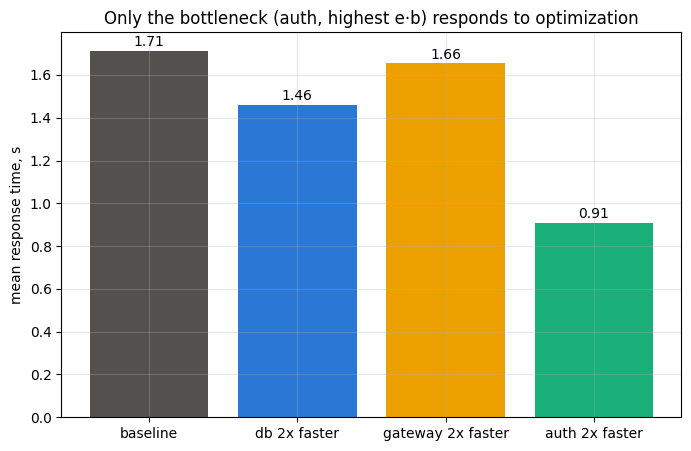

In [2]:
scenarios = {
    "baseline": B.copy(),
    "db 2x faster": B * np.array([1, 1, 0.5]),
    "gateway 2x faster": B * np.array([0.5, 1, 1]),
    "auth 2x faster": B * np.array([1, 0.5, 1]),
}
resp = {k: network_response(v) for k, v in scenarios.items()}

fig, ax = plt.subplots()
colors = ["#52514e", "#2a78d6", "#eda100", "#1baf7a"]
ax.bar(resp.keys(), resp.values(), color=colors)
for i, (k, v) in enumerate(resp.items()):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
ax.set_ylabel("mean response time, s")
ax.set_title("Only the bottleneck (auth, highest e·b) responds to optimization")
plt.show()

Halving the DB time — the "obviously slow" node — buys ~10%. Halving the gateway buys ~3%.
Halving the bottleneck **halves its demand** and cuts the response time by ~40%.

## 2. In closed networks the bottleneck caps throughput entirely

For a closed network, `X(N) → 1 / max_i(e_i · b_i)` as N grows — the asymptote *is* the
bottleneck demand, nothing else survives in the limit.

visit ratios:

[1.  0.5 0.4]

 demands:

[0.02  0.03  0.032]

 bound 1/max D = 31.25

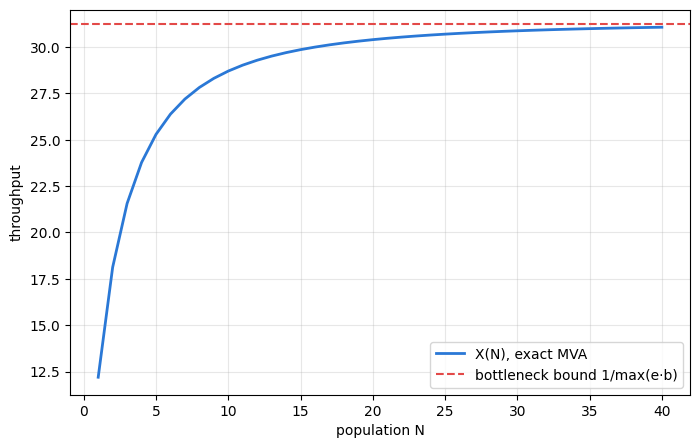

In [3]:
from most_queue.theory.networks.closed_network import ClosedNetworkCalc

# central server model: CPU visited every cycle, two disks
routing = np.array([
    [0.1, 0.5, 0.4],
    [1.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
])
b = [0.02, 0.06, 0.08]

calc = ClosedNetworkCalc()
calc.set_sources(R=routing, N=1)
calc.set_nodes(b=b, n=[1, 1, 1])
e = calc.visit_ratios()
demands = e * np.array(b)
x_max = 1.0 / demands.max()
print("visit ratios:", e, " demands:", demands.round(3), f" bound 1/max D = {x_max:.2f}")

ns = np.arange(1, 41)
xs = []
for n in ns:
    c = ClosedNetworkCalc()
    c.set_sources(R=routing, N=int(n))
    c.set_nodes(b=b, n=[1, 1, 1])
    xs.append(c.run().throughput)

fig, ax = plt.subplots()
ax.plot(ns, xs, lw=2, color="#2a78d6", label="X(N), exact MVA")
ax.axhline(x_max, color="#e34948", ls="--", label="bottleneck bound 1/max(e·b)")
ax.set_xlabel("population N"); ax.set_ylabel("throughput"); ax.legend()
plt.show()

## Takeaway

- Rank services by **demand** `e_i · b_i` (visits × time per visit), not by per-call latency.
  The bottleneck is often the *fast* service everyone calls three times.
- Optimizing a non-bottleneck node is capped by its share of total demand — usually a few
  percent (Amdahl's law in queueing clothes).
- Closed-network throughput converges to `1 / max(e_i·b_i)`; adding users past the knee changes
  *waiting*, never *throughput*.
- The visit ratios `e_i` come from the routing matrix (`ClosedNetworkCalc.visit_ratios()`,
  traffic equations in the open case) — measure them, don't guess.